In [1]:
import platform
if 'mac' in platform.platform():
    BASE_DIR = "/Users/USER/vrtopc/"
    DATA_DIR = "/media/data/vrtopc"
else:
    BASE_DIR = "/home/USER/vr_to_pc/"
    DATA_DIR = "/media/data/vrtopc"

import sys
sys.path.append(BASE_DIR)

### Parameters

In [2]:
SEED = 7

BY = 'day'

CLUSTER_ALGO = 'gm' # 'spectral' or 'gm'

COLUMNS_RIAB = ['speed_mean', 'speed_ct', 'rs_std', 'thigmotaxis']

COLS = ['speed_js', 'rs_js', 'tm_js']

'''
- 'norm_then_agg' works for all columns combinations
- 'agg_then_norm' works only when the chosen columns use the same distance (e.g. js or pdist)
- None works only when the chosen columns are the pdist
'''
NORMALIZATION = 'norm_then_agg' # 'norm_then_agg', 'agg_then_norm', or None (no normalization, works only with pdist)


### Imports

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option('display.width', 150)
import seaborn as sns
import os

%matplotlib inline

In [4]:
def mscatter(x, y , ax=None, m=None, **kw):
    import matplotlib.markers as mmarkers
    if not ax: ax=plt.gca()
    sc = ax.scatter(x,y,**kw)
    if (m is not None) and (len(m)==len(x)):
        paths = []
        for marker in m:
            if isinstance(marker, mmarkers.MarkerStyle):
                marker_obj = marker
            else:
                marker_obj = mmarkers.MarkerStyle(marker)
            path = marker_obj.get_path().transformed(
                        marker_obj.get_transform())
            paths.append(path)
        sc.set_paths(paths)
    return sc

### Load Grid Search Results

In [5]:
CLUSTER_COL = f'cluster_idx_{CLUSTER_ALGO}'

In [6]:
df_dir = os.path.join(DATA_DIR, 'cluster_locomotion', f'by_{BY}')
df = pd.read_pickle(os.path.join(df_dir, f'grid_search_{CLUSTER_ALGO}_{SEED}.pkl'))
df = df.reset_index()

In [7]:
df[COLS].describe()

,speed_js,rs_js,tm_js
count,2772.000000,2772.000000,2772.000000
mean,0.255266,0.188365,0.159919
std,0.087293,0.053602,0.060463
min,0.061892,0.111467,0.061717
25%,0.195722,0.144118,0.110753
50%,0.246723,0.171099,0.142170
75%,0.315776,0.221435,0.200118
max,0.459557,0.291132,0.336095


In [8]:
if NORMALIZATION is None:
    print("No normalization")
    # this only works with pdist, because the similarity is computed
    # as 1 - distance always, even without normalization
    df['distance_agg'] = df[COLS].mean(axis=1)
    df['similarity_agg'] = (1 - df[COLS]).mean(axis=1)
elif NORMALIZATION == 'agg_then_norm':
    print("Aggregate (average) the distances, then min-max normalize and convert to similarity")
    df['distance_agg'] = df[COLS].mean(axis=1)
    _min = df['distance_agg'].min()
    _max = df['distance_agg'].max()
    df['distance_agg'] = (df['distance_agg'] - _min) / (_max - _min)
    # now can convert distance to similarity because it is 0-1 normalized
    df['similarity_agg'] = 1 - df['distance_agg']
elif NORMALIZATION == 'norm_then_agg':
    print("Min-max normalize each distance, then aggregate (average)")
    _min = df[COLS].min()
    _max = df[COLS].max()
    df[COLS] = (df[COLS] - _min) / (_max - _min)

    df['distance_agg'] = df[COLS].mean(axis=1)
    df['similarity_agg'] = 1 - df['distance_agg']
else:
    raise ValueError(f"Unknown normalization: {NORMALIZATION}")


Min-max normalize each distance, then aggregate (average)


In [9]:
df['distance_agg'].describe()

count    2772.000000
mean        0.424062
std         0.167464
min         0.080922
25%         0.301464
50%         0.437553
75%         0.548352
max         0.870419
Name: distance_agg, dtype: float64

In [10]:
pd.set_option('display.max_columns', None)

      speed_mean  speed_ct  rs_std  thigmotaxis  speed_js     rs_js  pos_occ_pdist  hdtp_pdist  tm_pdist  distance_agg
692      0.03794      2.00  0.7854          0.6  0.323431  0.925007       0.184670    0.616776  0.033961      0.416769
92       0.02956      1.35  0.5236          0.6  0.411521  0.878009       0.118678    0.629252  0.046684      0.416829
764      0.04299      0.70  0.5236          0.6  0.314388  0.864686       0.168770    0.593755  0.150283      0.418376
548      0.03794      0.70  1.5708          0.6  0.387375  0.892493       0.053236    0.690664  0.069784      0.418710
596      0.03794      1.35  0.5236          0.6  0.324447  0.881057       0.254997    0.574095  0.078549      0.422629
1016     0.04870      0.70  0.5236          0.6  0.350278  0.841973       0.129734    0.546542  0.246659      0.423037
800      0.04299      0.70  1.5708          0.6  0.392457  0.875126       0.054668    0.723312  0.088342      0.426781

 speed_js
      speed_mean  speed_ct  rs_std  t

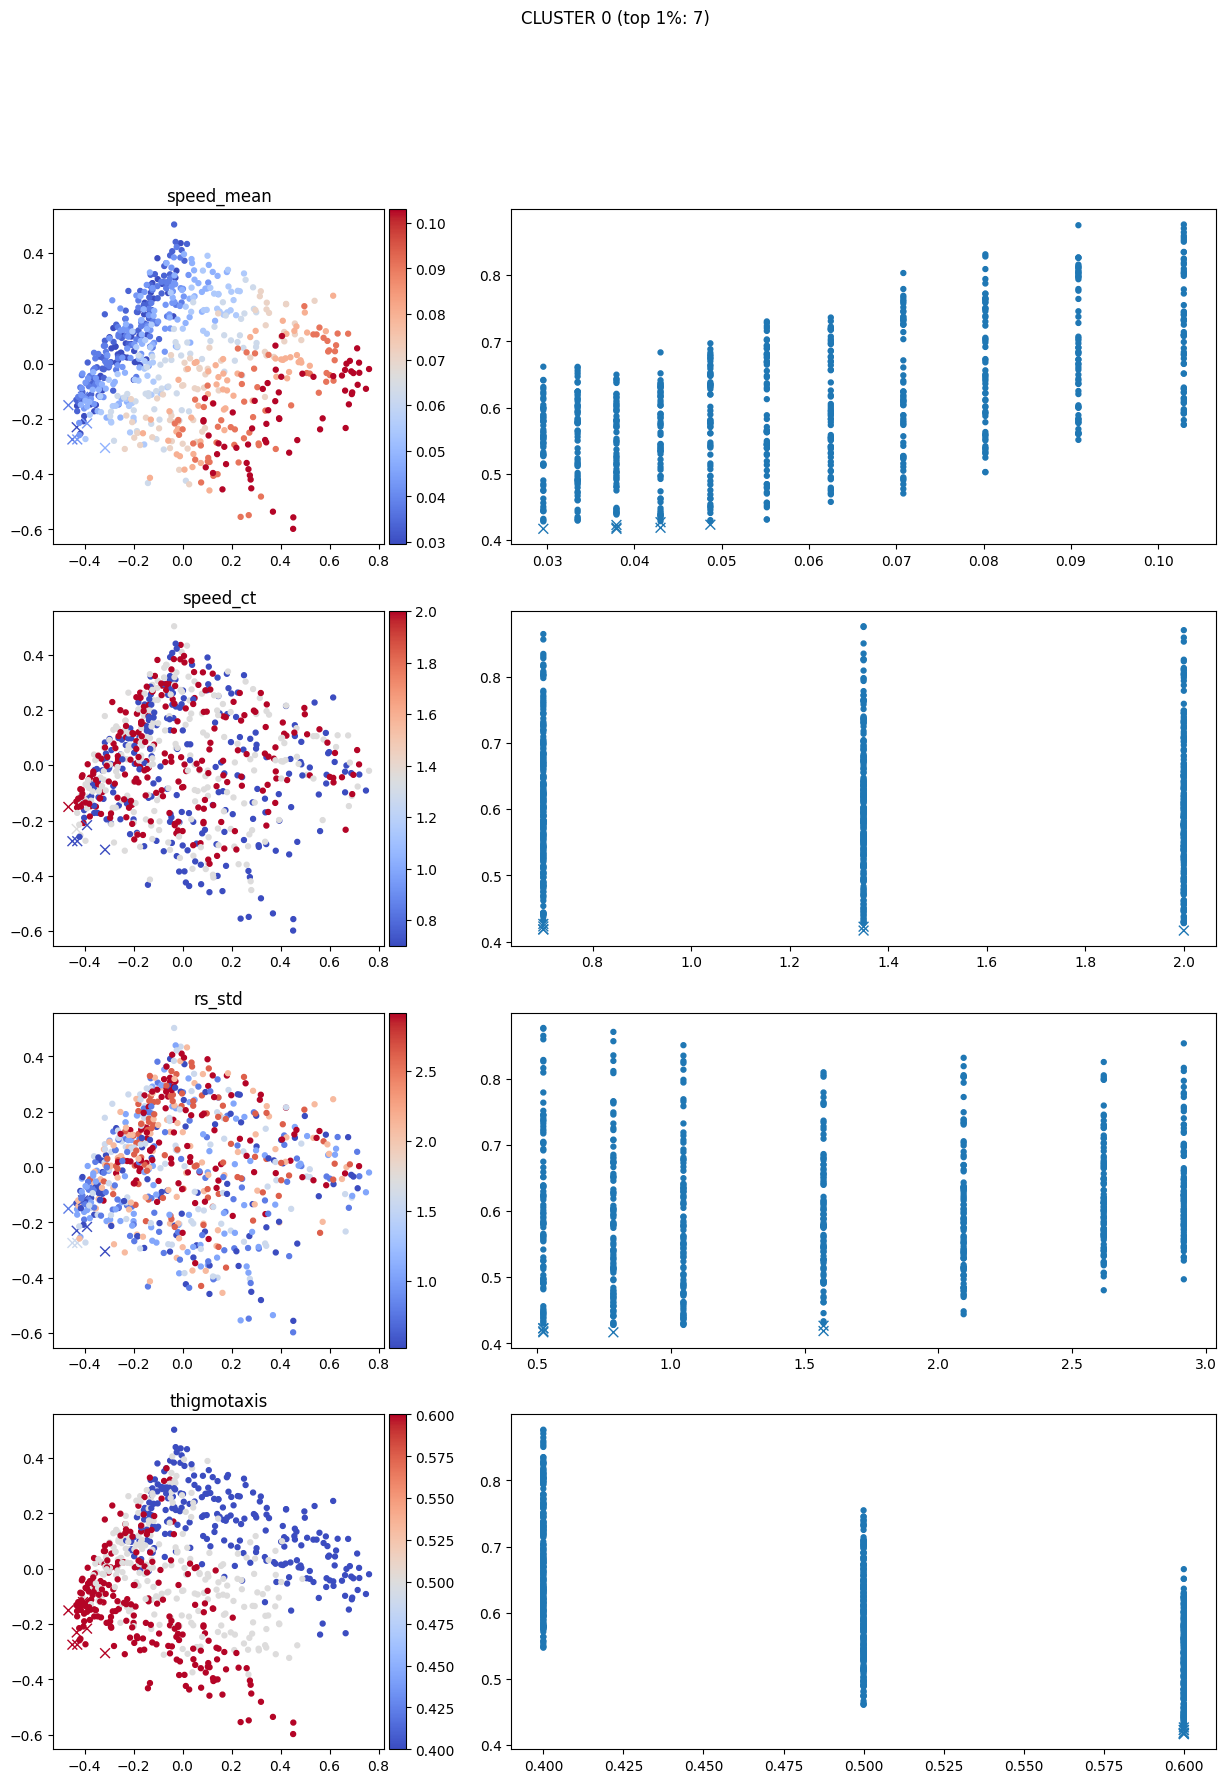

      speed_mean  speed_ct  rs_std  thigmotaxis  speed_js     rs_js  pos_occ_pdist  hdtp_pdist  tm_pdist  distance_agg
2409     0.09087      1.35  2.0944          0.6  0.013942  0.157860       0.072753    0.212191  0.202942      0.131937
2181     0.08021      1.35  2.9172          0.6  0.022572  0.126223       0.066295    0.291240  0.170641      0.135394
1809     0.07081      0.70  1.5708          0.6  0.095238  0.174717       0.048501    0.154563  0.239009      0.142406
2673     0.10295      1.35  2.6180          0.6  0.037546  0.137078       0.076396    0.182678  0.289532      0.144646
2073     0.08021      0.70  2.0944          0.6  0.028407  0.127183       0.207242    0.186305  0.208276      0.151483
2049     0.08021      0.70  1.0472          0.6  0.056578  0.142156       0.069879    0.138970  0.380148      0.157546
2325     0.09087      0.70  2.0944          0.6  0.051699  0.142358       0.122874    0.194615  0.276331      0.157575

 speed_js
      speed_mean  speed_ct  rs_std  t

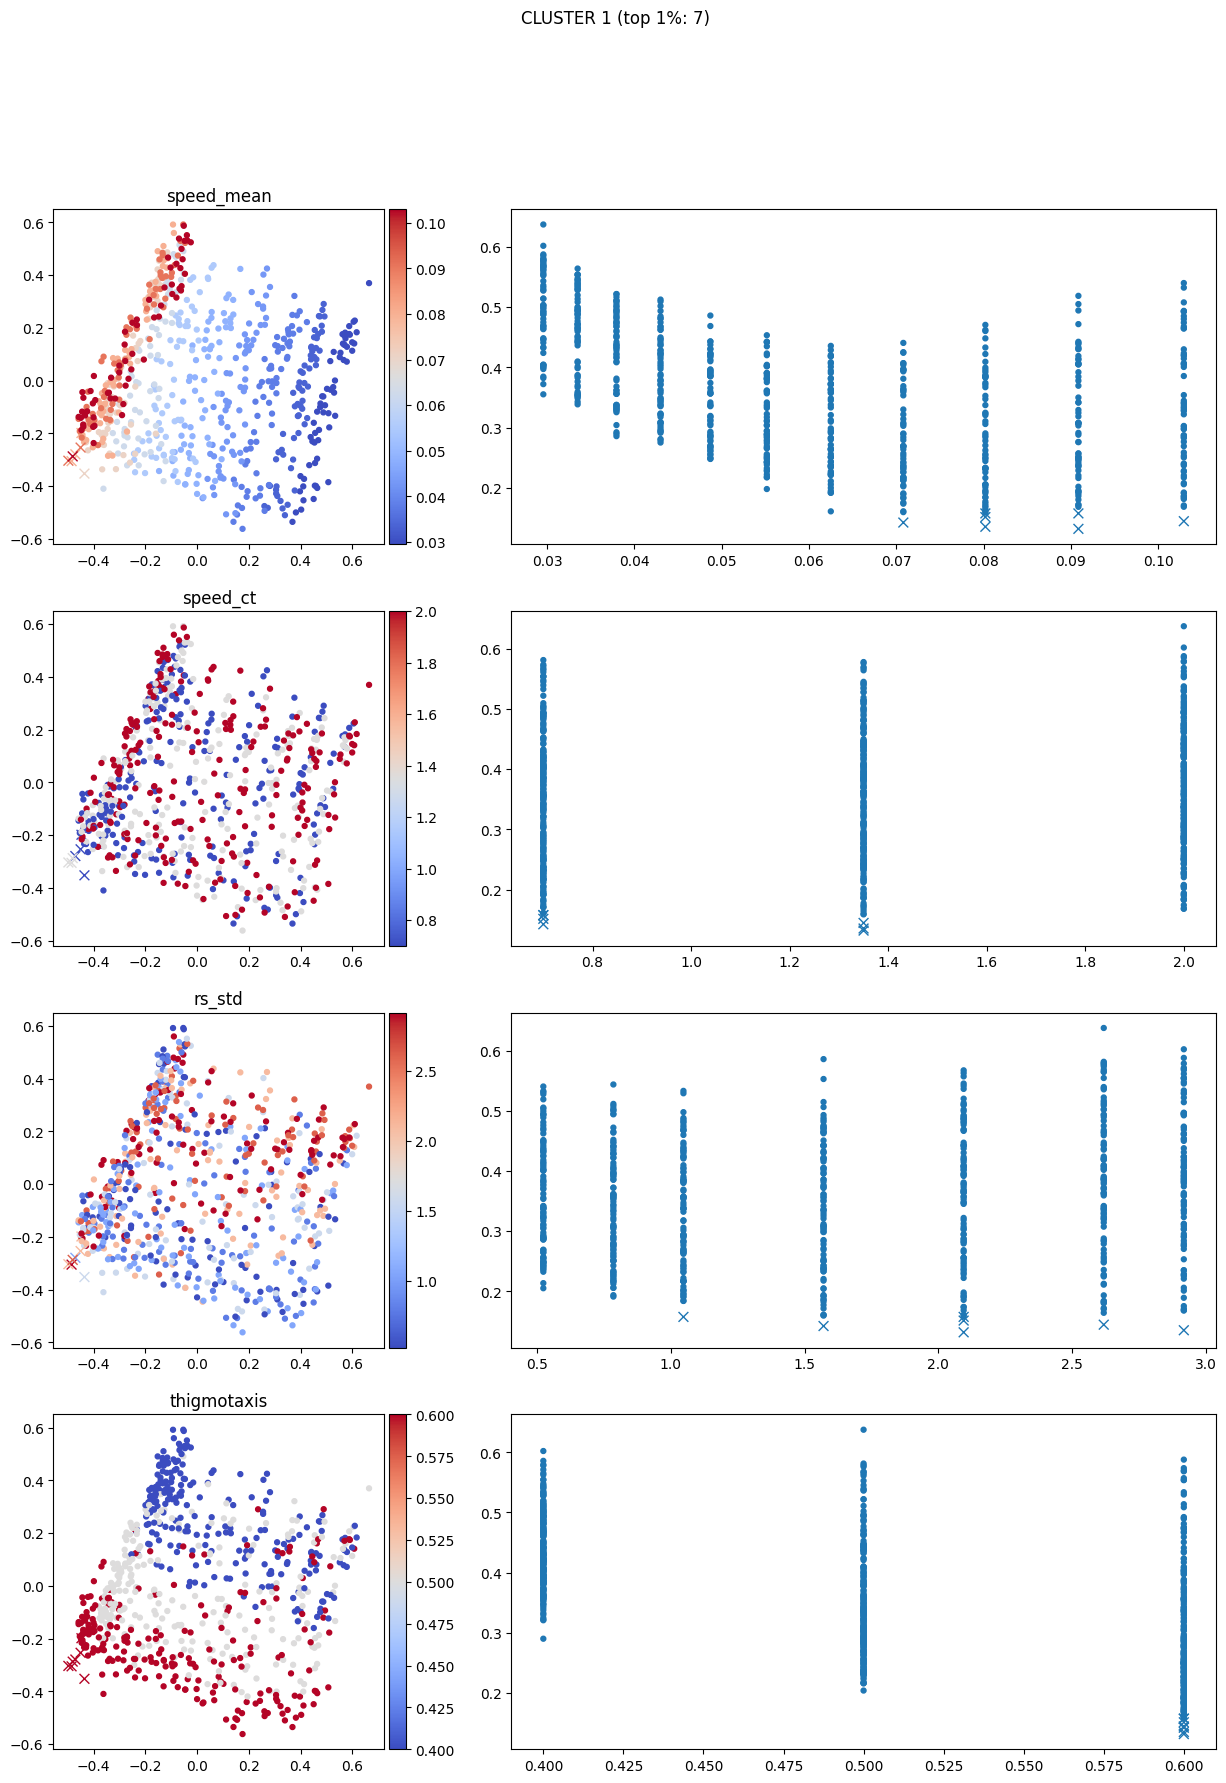

      speed_mean  speed_ct  rs_std  thigmotaxis  speed_js     rs_js  pos_occ_pdist  hdtp_pdist  tm_pdist  distance_agg
1906     0.07081      1.35  2.0944          0.6  0.353667  0.400201       0.309523    0.271394  0.122664      0.291490
1462     0.05517      2.00  1.0472          0.6  0.318153  0.446104       0.333647    0.256877  0.137237      0.298404
1390     0.05517      1.35  1.5708          0.6  0.340261  0.420372       0.318022    0.340582  0.073189      0.298485
1726     0.06250      2.00  1.5708          0.6  0.297472  0.419480       0.338956    0.318806  0.123167      0.299576
1654     0.06250      1.35  2.0944          0.6  0.332996  0.424481       0.284334    0.344518  0.111971      0.299660
1990     0.07081      2.00  2.0944          0.6  0.315194  0.431274       0.297696    0.334538  0.129455      0.301631
1714     0.06250      2.00  1.0472          0.6  0.274291  0.426232       0.365398    0.267840  0.186588      0.304070

 speed_js
      speed_mean  speed_ct  rs_std  t

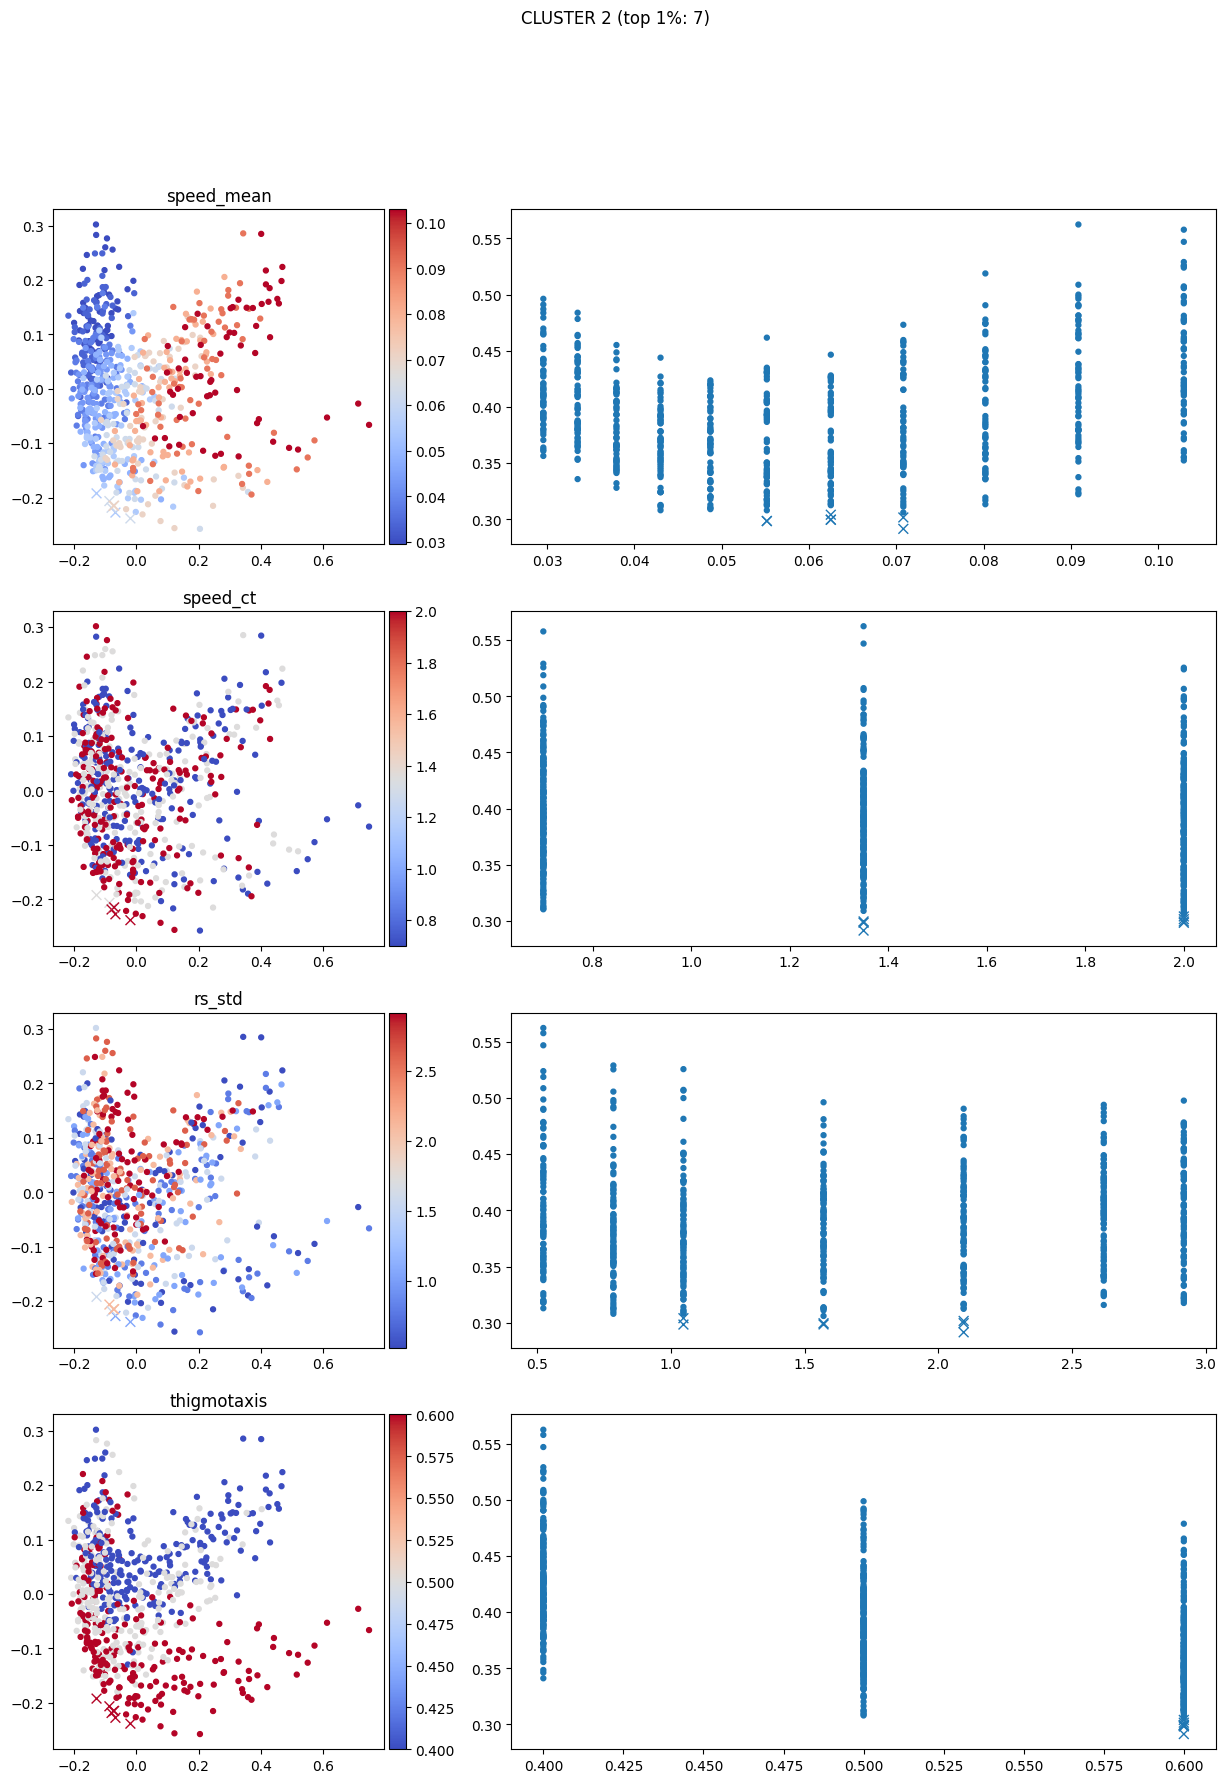

      speed_mean  speed_ct  rs_std  thigmotaxis  speed_js     rs_js  pos_occ_pdist  hdtp_pdist  tm_pdist  distance_agg
2163     0.08021      1.35  2.6180          0.4  0.301888  0.108490       0.087435    0.139632  0.209769      0.169443
2151     0.08021      1.35  2.0944          0.4  0.304503  0.138280       0.128201    0.130801  0.210975      0.182552
1587     0.06250      0.70  2.9172          0.4  0.326156  0.128137       0.091091    0.215722  0.154932      0.183207
2095     0.08021      0.70  2.9172          0.5  0.269699  0.071857       0.301143    0.143398  0.131227      0.183465
2583     0.10295      0.70  2.6180          0.4  0.357710  0.096105       0.140645    0.063956  0.263190      0.184321
2427     0.09087      1.35  2.9172          0.4  0.325429  0.112833       0.075476    0.169839  0.241611      0.185037
1839     0.07081      0.70  2.9172          0.4  0.295767  0.116739       0.205655    0.146398  0.163565      0.185625

 speed_js
      speed_mean  speed_ct  rs_std  t

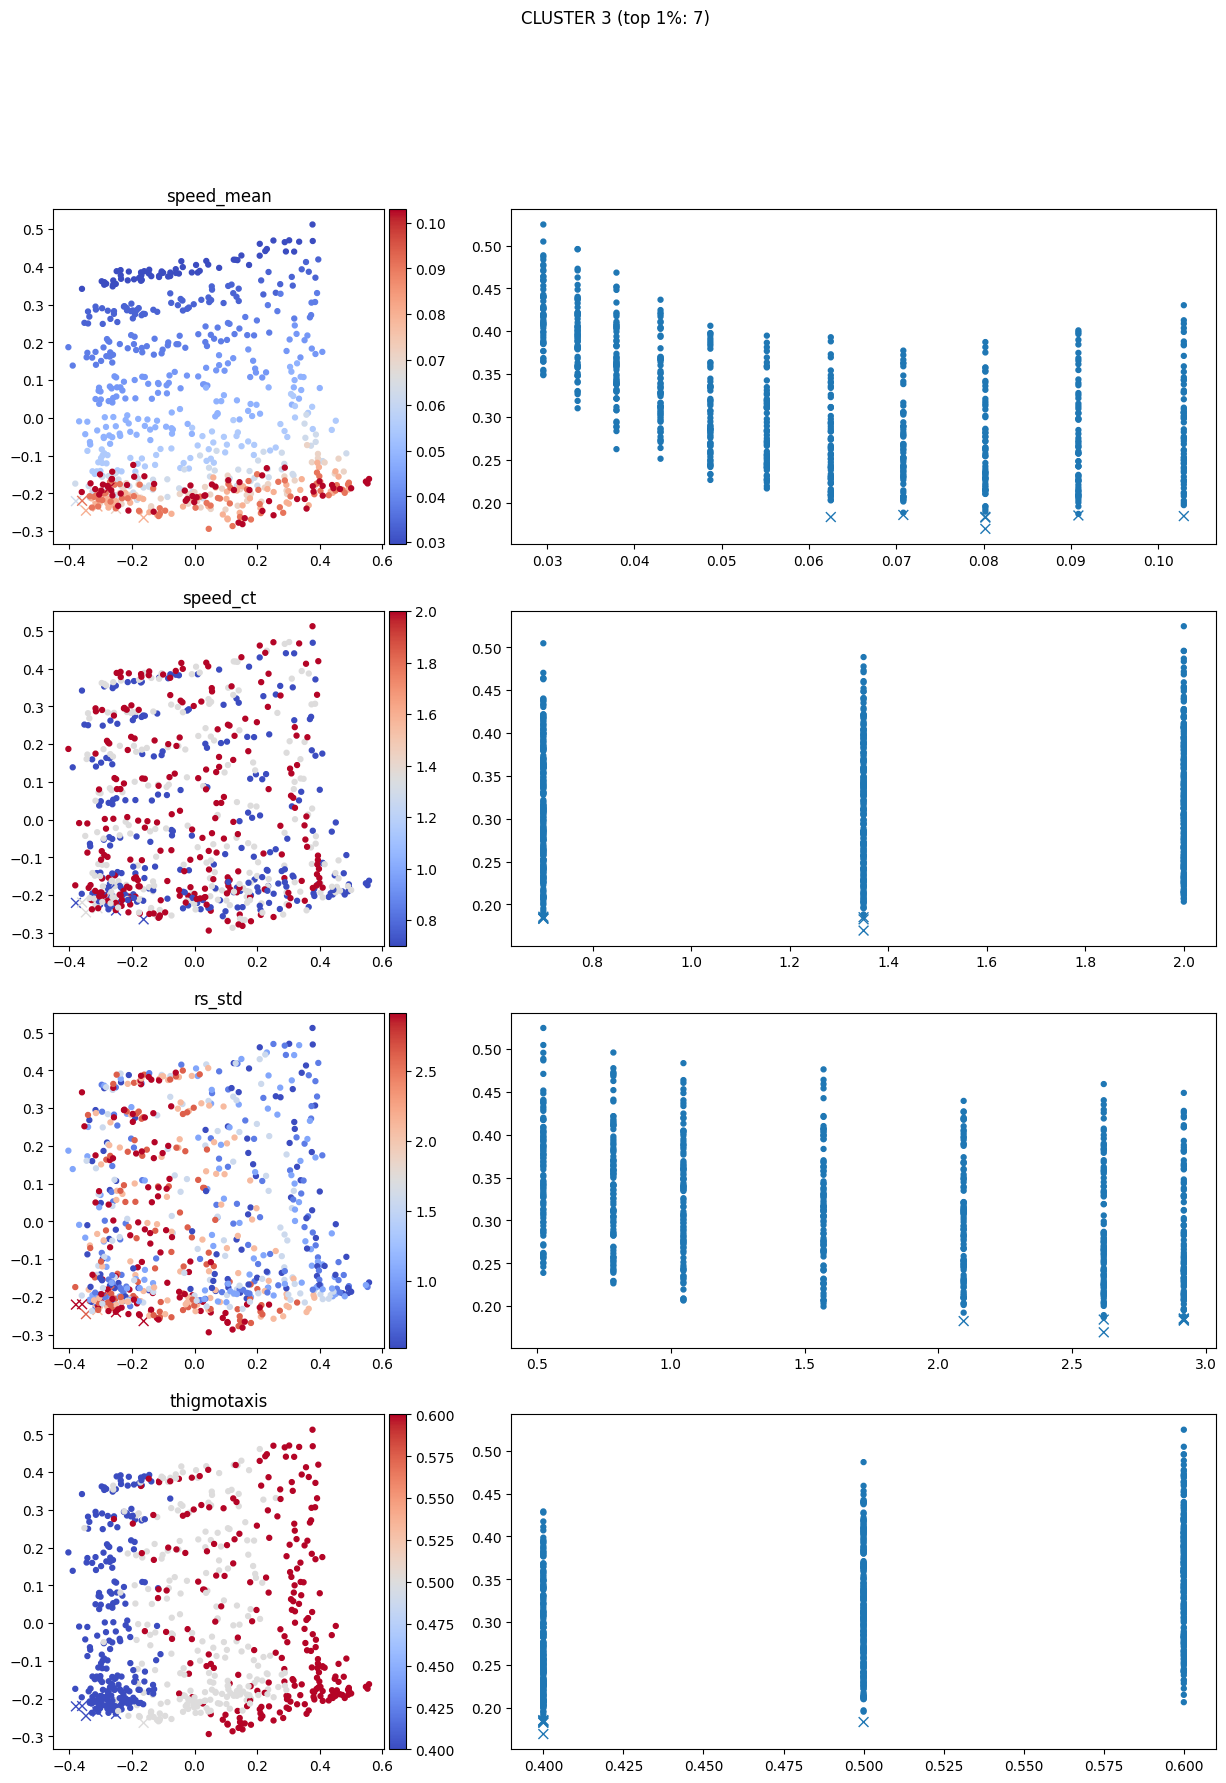

In [ ]:
from sklearn.decomposition import PCA
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib import colormaps
cmap = colormaps['coolwarm']

for cluster_idx in range(max(df[CLUSTER_COL])+1):
    df_cluster = df[df[CLUSTER_COL] == cluster_idx]
    pca_v = PCA(n_components=2).fit_transform(df_cluster[COLS])

    is_top_1perc = df_cluster['distance_agg'] < df_cluster['distance_agg'].quantile(0.01)
    print(df_cluster[is_top_1perc][COLUMNS_RIAB+COLS+['distance_agg']].sort_values(by='distance_agg'))
    for c in COLS:
        print('\n', c)
        print(
            df_cluster[df_cluster[c] < df_cluster[c].quantile(0.01)]
            [COLUMNS_RIAB+[c]+['distance_agg']]
            .sort_values(by=c)
        )

    # plot the embeddings, also add the ages as labels
    fig, axs = plt.subplots(len(COLUMNS_RIAB), 2, width_ratios=[1, 2], figsize=(15, 5*len(COLUMNS_RIAB)))
    for i, c in enumerate(COLUMNS_RIAB):
        _min, _max = df_cluster[c].min(), df_cluster[c].max()
        c_norm = (df_cluster[c] - _min) / (_max - _min)
        markers = ['x' if x else '.' for x in is_top_1perc]
        ms = mscatter(
            pca_v[:, 0], pca_v[:, 1],
            ax=axs[i,0],
            m=markers, s=50,
            c=df_cluster[c], cmap='coolwarm',
        )
        divider = make_axes_locatable(axs[i,0])
        cax = divider.append_axes('right', size='5%', pad=0.05)
        fig.colorbar(ms, cax=cax, orientation='vertical')
        axs[i,0].set_title(c)

        mscatter(
            df_cluster[c], df_cluster['distance_agg'],
            ax=axs[i,1],
            m=markers, s=50,
        )
    plt.suptitle(f"CLUSTER {cluster_idx} (top 1%: {sum(is_top_1perc)})")
    # plt.tight_layout()
    plt.show()